# 📊 Voorspelling Jeugdpopulatie Almere (2019–2025)
## Gemeente Notebook
Dit notebook bevat het volledige CRISP-DM proces: van probleemdefinitie tot evaluatie.

## Business Understanding
**Probleem:**
Beschrijf hier het probleem van de gemeente Almere.

**Doel:**
Wat willen we voorspellen?

**Waarom is dit belangrijk?**
Koppel dit aan zorgcapaciteit en beleidsplanning.

In [163]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Ruwe CBS dataset inladen
df_cbs = pd.read_csv("../../data/raw/CBS_Kerncijfers.csv", sep=";")

print("Shape:", df_cbs.shape)
df_cbs.head()

Shape: (1536, 411)


,ID,Peildatum,WijkenEnBuurten,Gemeentenaam_1,SoortRegio_2,Codering_3,IndelingswijzigingGemeenteWijkBuurt_4,AantalInwoners_5,Mannen_6,Vrouwen_7,...,PersonenPerSoortUitkeringAO_81,PersonenPerSoortUitkeringWW_82,PersonenPerSoortUitkeringAOW_83,JongerenMetJeugdzorgInNatura_84,PercentageJongerenMetJeugdzorg_85,WmoClienten_86,WmoClientenRelatief_87,TotaalDiefstalUitWoningSchuurED_88,VernielingMisdrijfTegenOpenbareOrde_89,GeweldsEnSeksueleMisdrijven_90
0,384,1-1-2025,GM0034,Almere,Gemeente,GM0034,1.0,229574,113738,115836,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,385,1-1-2025,WK003401,Almere,Wijk,WK003401,1.0,1810,880,930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,386,1-1-2025,BU00340101,Almere,Buurt,BU00340101,1.0,795,415,385,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,387,1-1-2025,BU00340102,Almere,Buurt,BU00340102,1.0,1010,465,545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,388,1-1-2025,WK003402,Almere,Wijk,WK003402,1.0,2890,1395,1500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Preparation FASE 1


**Eerste verkenning (Wail + Faysal)**

In [164]:
# Overzicht: kolommen, types, missende waarden
df_cbs.info()

# Beschrijvende statistiek (numeriek)
df_cbs.describe()
# Missende waarden overzicht (aantallen + percentages)
missing_counts = df_cbs.isnull().sum()
missing_pct = (missing_counts / len(df_cbs)) * 100

missing_overview = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_pct
}).sort_values("missing_percentage", ascending=False)

missing_overview

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Columns: 411 entries, ID to GeweldsEnSeksueleMisdrijven_90
dtypes: float64(387), int64(13), object(11)
memory usage: 4.8+ MB


,missing_count,missing_percentage
HJVervoerInformatieEnCommunicatie_101,1536,100.0
GemiddeldeElektriciteitsleveringTotaal_53,1536,100.0
PersonenPerSoortUitkeringBijstand_89,1536,100.0
PersonenPerSoortUitkeringAO_90,1536,100.0
PersonenPerSoortUitkeringWW_91,1536,100.0
...,...,...
Gehuwd_14,0,0.0
Gescheiden_15,0,0.0
Verweduwd_16,0,0.0
Peildatum,0,0.0


**Filter op Almere en op wijken (Ismael)**

In [165]:
# kolomnamen opschonen
df_cbs.columns = df_cbs.columns.astype(str).str.strip()

# gemeentenaam opschonen
df_cbs["Gemeentenaam_1"] = df_cbs["Gemeentenaam_1"].astype(str).str.strip()

# filter Almere
df_almere = df_cbs[df_cbs["Gemeentenaam_1"] == "Almere"].copy()
print("Shape Almere:", df_almere.shape)

# waardes opschonen + filter wijken
df_almere["SoortRegio_2"] = df_almere["SoortRegio_2"].astype(str).str.strip()
df_almere["Codering_3"] = df_almere["Codering_3"].astype(str).str.strip()

df_wijk = df_almere[df_almere["SoortRegio_2"] == "Wijk"].copy()
df_wijk = df_wijk[df_wijk["Codering_3"].str.startswith("WK")].copy()

print("Shape wijken:", df_wijk.shape)
df_wijk.head()

Shape Almere: (1536, 411)
Shape wijken: (308, 411)


,ID,Peildatum,WijkenEnBuurten,Gemeentenaam_1,SoortRegio_2,Codering_3,IndelingswijzigingGemeenteWijkBuurt_4,AantalInwoners_5,Mannen_6,Vrouwen_7,...,PersonenPerSoortUitkeringAO_81,PersonenPerSoortUitkeringWW_82,PersonenPerSoortUitkeringAOW_83,JongerenMetJeugdzorgInNatura_84,PercentageJongerenMetJeugdzorg_85,WmoClienten_86,WmoClientenRelatief_87,TotaalDiefstalUitWoningSchuurED_88,VernielingMisdrijfTegenOpenbareOrde_89,GeweldsEnSeksueleMisdrijven_90
1,385,1-1-2025,WK003401,Almere,Wijk,WK003401,1.0,1810,880,930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,388,1-1-2025,WK003402,Almere,Wijk,WK003402,1.0,2890,1395,1500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,394,1-1-2025,WK003403,Almere,Wijk,WK003403,1.0,2500,1205,1300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,399,1-1-2025,WK003404,Almere,Wijk,WK003404,1.0,2220,1065,1155,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,403,1-1-2025,WK003405,Almere,Wijk,WK003405,1.0,2365,1130,1235,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Basis datakwaliteit checks (Wail + Noah + Ismael)**

In [166]:
# Dubbele combinaties wijkcode + peildatum
dup_count = df_wijk.duplicated(subset=["Codering_3", "Peildatum"]).sum()
print("Duplicaten (Codering_3 + Peildatum):", dup_count)

# Volledig dubbele rijen
full_dup = df_wijk.duplicated().sum()
print("Volledig dubbele rijen:", full_dup)

# Unieke wijken
print("Aantal unieke wijken:", df_wijk["Codering_3"].nunique())

# Aantal jaren per wijk
jaren_per_wijk = df_wijk.groupby("Codering_3")["Peildatum"].nunique()
jaren_per_wijk.describe()

# Missende jaren per wijk
alle_jaren = sorted(df_wijk["Peildatum"].dropna().unique())

print("Missende jaren per wijk (alleen wijken met missende jaren):")
for wijk, groep in df_wijk.groupby("Codering_3"):
    aanwezige = sorted(groep["Peildatum"].dropna().unique())
    missend = sorted(set(alle_jaren) - set(aanwezige))
    if missend:
        print(f"{wijk} mist: {missend}")

Duplicaten (Codering_3 + Peildatum): 0
Volledig dubbele rijen: 0
Aantal unieke wijken: 71
Missende jaren per wijk (alleen wijken met missende jaren):
WK003407 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003408 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003409 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003410 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003411 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003414 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003415 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003416 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003417 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003418 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003419 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003420 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003421 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003422 mist: ['1

**Kernvariabelen opschonen (Bo + Faysal)**

In [167]:
cols_check = ["AantalInwoners_5", "k_0Tot15Jaar_8", "k_15Tot25Jaar_9"]

# naar numeriek
for col in cols_check:
    df_wijk[col] = pd.to_numeric(df_wijk[col], errors="coerce")

# NaN eruit
df_wijk = df_wijk.dropna(subset=cols_check)

# 0-waarden eruit
for col in cols_check:
    df_wijk = df_wijk[df_wijk[col] != 0]

print("Shape na opschonen kernvariabelen:", df_wijk.shape)
df_wijk[cols_check].describe()

# Extra logische checks (Faysel)
kol_totaal = "AantalInwoners_5"
kol_0_15 = "k_0Tot15Jaar_8"
kol_15_25 = "k_15Tot25Jaar_9"

checks = {
    "negatief_0_15": (df_wijk[kol_0_15] < 0).sum(),
    "negatief_15_25": (df_wijk[kol_15_25] < 0).sum(),
    "negatief_totaal": (df_wijk[kol_totaal] < 0).sum(),
    "0_15_groter_dan_totaal": (df_wijk[kol_0_15] > df_wijk[kol_totaal]).sum(),
    "15_25_groter_dan_totaal": (df_wijk[kol_15_25] > df_wijk[kol_totaal]).sum(),
}
checks

Shape na opschonen kernvariabelen: (237, 411)


{'negatief_0_15': np.int64(0),
 'negatief_15_25': np.int64(0),
 'negatief_totaal': np.int64(0),
 '0_15_groter_dan_totaal': np.int64(0),
 '15_25_groter_dan_totaal': np.int64(0)}

**Kolommen duidelijk maken + tijdstructuur (Ismael + Mo + Wail)**

In [ ]:
# Kolommen hernoemen naar duidelijke namen
df_wijk = df_wijk.rename(columns={
    "WijkenEnBuurten": "Wijk",
    "Codering_3": "WijkCode",
    "AantalInwoners_5": "AantalInwoners",
    "k_0Tot15Jaar_8": "Aantal_0_15",
    "k_15Tot25Jaar_9": "Aantal_15_25",
})

# Peildatum omzetten naar datetime + Jaar maken
df_wijk["Peildatum"] = pd.to_datetime(df_wijk["Peildatum"], errors="coerce")
df_wijk["Jaar"] = df_wijk["Peildatum"].dt.year

# erwijder rijen zonder geldige datum/jaar
df_wijk = df_wijk.dropna(subset=["Peildatum", "Jaar"]).copy()
df_wijk["Jaar"] = df_wijk["Jaar"].astype(int)

# sorteren (handig voor tijdreeksen)
df_wijk = df_wijk.sort_values(["WijkCode", "Jaar"]).reset_index(drop=True)

# Duplicaten check (wijkcode + jaar)
dup_wijk_jaar = df_wijk.duplicated(subset=["WijkCode", "Jaar"]).sum()
print("Duplicaten (WijkCode + Jaar):", dup_wijk_jaar)

# Kolommen selecteren (Wail)
keep_cols = [
    "Peildatum", "Jaar", "WijkCode", "Wijk",
    "AantalInwoners", "Aantal_0_15", "Aantal_15_25"
]

missing = [c for c in keep_cols if c not in df_wijk.columns]
if missing:
    print("Ontbrekende kolommen:", missing)

df_wijk = df_wijk[[c for c in keep_cols if c in df_wijk.columns]].copy()

print("Kolommen na selectie:", df_wijk.columns.tolist())
print("Shape na selectie:", df_wijk.shape)

df_wijk.head()

Duplicaten (WijkCode + Jaar): 0
Kolommen na selectie: ['Peildatum', 'Jaar', 'WijkCode', 'Wijk', 'AantalInwoners', 'Aantal_0_15', 'Aantal_15_25']
Shape na selectie: (237, 7)


,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465
4,2022-01-01,2022,WK003401,WK003401,1635,175,150


**Percentages toevoegen (Faysel) – handig voor latere analyse**

In [169]:
df_wijk["pct_0_15"] = (df_wijk["Aantal_0_15"] / df_wijk["AantalInwoners"]) * 100
df_wijk["pct_15_25"] = (df_wijk["Aantal_15_25"] / df_wijk["AantalInwoners"]) * 100

df_wijk[["pct_0_15", "pct_15_25"]].describe()

,pct_0_15,pct_15_25
count,237.000000,237.000000
mean,18.277507,12.805460
std,6.034239,6.198061
min,2.083333,6.250000
25%,15.671642,10.135135
50%,17.287234,11.790393
75%,19.288646,14.258735
max,57.142857,83.333333


**Export: dataset klaar voor analyse**

In [170]:
output_path = Path("../../data/processed_Gezamenlijke/df_fase1_ready_for_analysis.csv")
df_wijk.to_csv(output_path, index=False)

output_path.as_posix()

'../../data/processed_Gezamenlijke/df_fase1_ready_for_analysis.csv'

##  Data Understanding FASE 2

In [171]:
df = pd.read_csv("../../data/processed_Gezamenlijke/df_fase1_ready_for_analysis.csv")
print("Shape:", df.shape)
df.head()


Shape: (237, 9)


,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25,pct_0_15,pct_15_25
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420,17.441860,10.618692
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415,17.245902,10.557377
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485,17.207304,10.676692
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465,17.764556,10.475988
4,2022-01-01,2022,WK003401,WK003401,1635,175,150,10.703364,9.174312


**Tijdreeks voorbereiden (Mo + Ismael)**

In [172]:
df["Peildatum"] = pd.to_datetime(df["Peildatum"], errors="coerce")
df["Jaar"] = df["Peildatum"].dt.year

df = df.sort_values(["Wijk", "Jaar"]).reset_index(drop=True)

df[["Wijk","Jaar"]].head()

,Wijk,Jaar
0,WK003401,2018
1,WK003401,2019
2,WK003401,2020
3,WK003401,2021
4,WK003401,2022


**Scatterplot relatie inwoners vs jongeren (Mo + Faysel)**

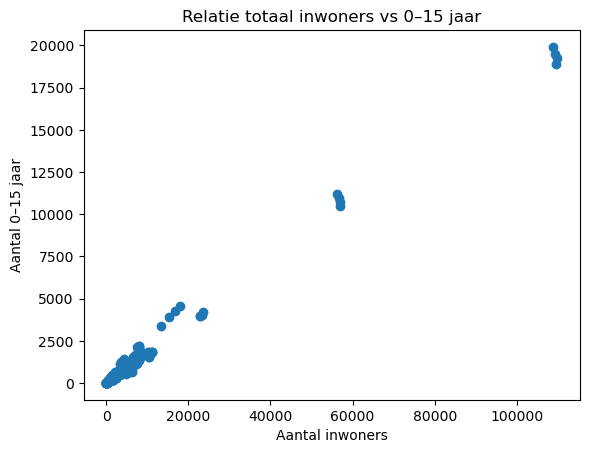

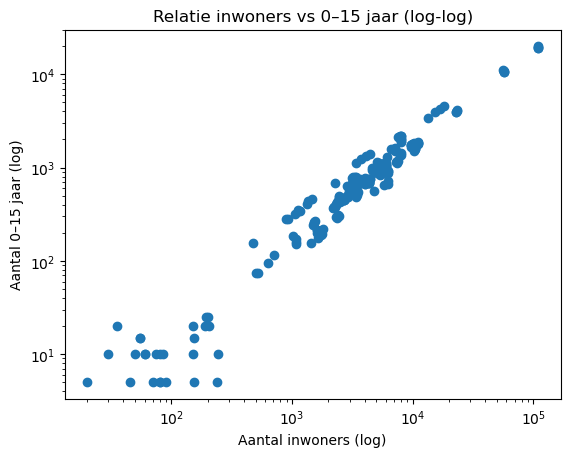

In [173]:
plt.scatter(df["AantalInwoners"], df["Aantal_0_15"])
plt.xlabel("Aantal inwoners")
plt.ylabel("Aantal 0–15 jaar")
plt.title("Relatie totaal inwoners vs 0–15 jaar")
plt.show()


plt.scatter(df["AantalInwoners"], df["Aantal_0_15"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Aantal inwoners (log)")
plt.ylabel("Aantal 0–15 jaar (log)")
plt.title("Relatie inwoners vs 0–15 jaar (log-log)")
plt.show()

**Trend van jongeren door de jaren (Mo)**

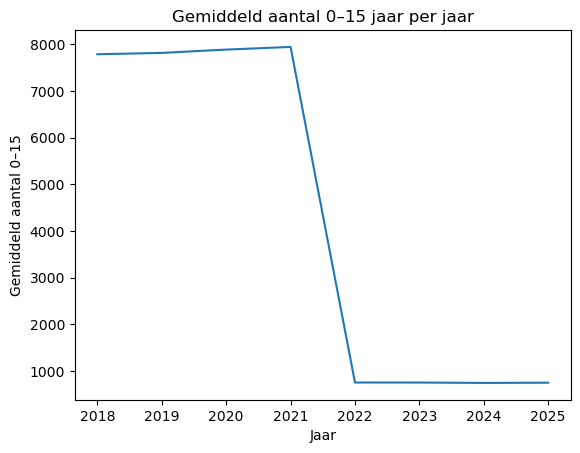

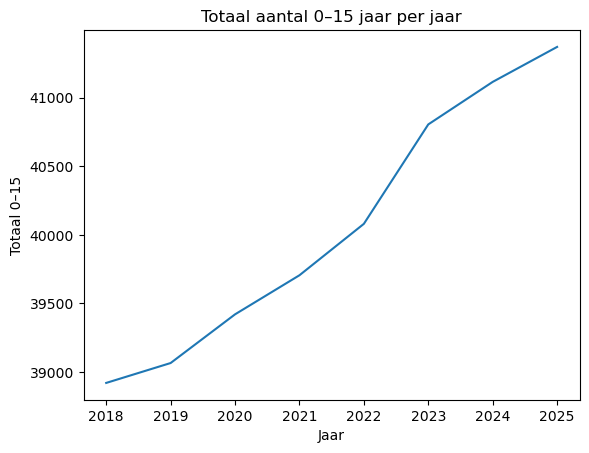

In [174]:
df.groupby("Jaar")["Aantal_0_15"].mean().plot()
plt.title("Gemiddeld aantal 0–15 jaar per jaar")
plt.xlabel("Jaar")
plt.ylabel("Gemiddeld aantal 0–15")
plt.show()


df.groupby("Jaar")["Aantal_0_15"].sum().plot()
plt.title("Totaal aantal 0–15 jaar per jaar")
plt.xlabel("Jaar")
plt.ylabel("Totaal 0–15")
plt.show()

**Vergelijking tussen wijken (Faysel)**

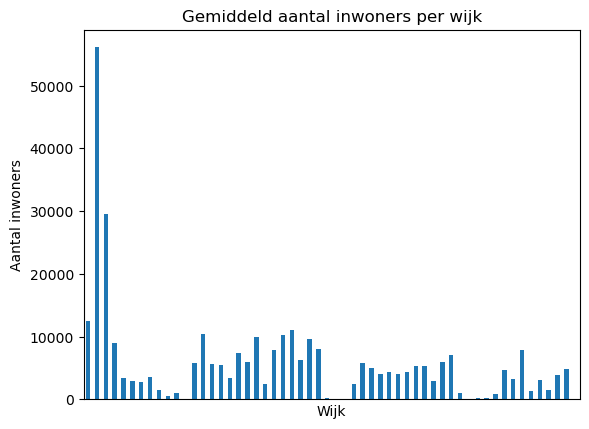

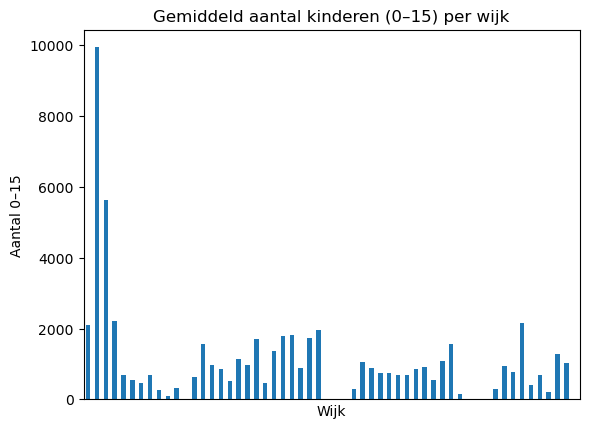

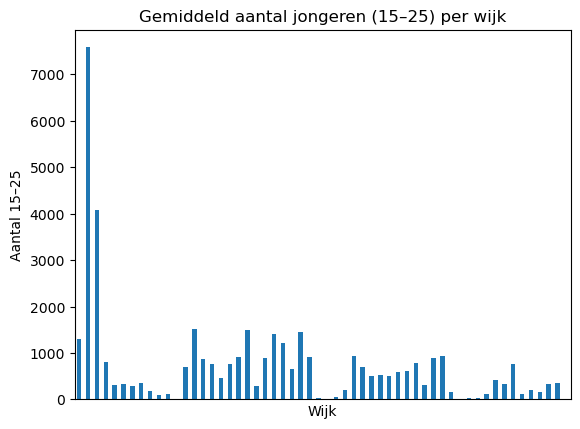

In [175]:
df.groupby("Wijk")["AantalInwoners"].mean().plot(kind="bar")
plt.title("Gemiddeld aantal inwoners per wijk")
plt.ylabel("Aantal inwoners")
plt.xticks([])
plt.show()

df.groupby("Wijk")["Aantal_0_15"].mean().plot(kind="bar")
plt.title("Gemiddeld aantal kinderen (0–15) per wijk")
plt.ylabel("Aantal 0–15")
plt.xticks([])
plt.show()

df.groupby("Wijk")["Aantal_15_25"].mean().plot(kind="bar")
plt.title("Gemiddeld aantal jongeren (15–25) per wijk")
plt.ylabel("Aantal 15–25")
plt.xticks([])
plt.show()

**Correlaties tussen variabelen (Faysal)**

In [176]:
df[["AantalInwoners", "Aantal_0_15", "Aantal_15_25"]].corr()

,AantalInwoners,Aantal_0_15,Aantal_15_25
AantalInwoners,1.000000,0.995671,0.996897
Aantal_0_15,0.995671,1.000000,0.989825
Aantal_15_25,0.996897,0.989825,1.000000


**Percentage jeugd berekenen (Ismael + Wail)**

In [177]:
df["pct_0_15"] = (df["Aantal_0_15"] / df["AantalInwoners"]) * 100
df["pct_15_25"] = (df["Aantal_15_25"] / df["AantalInwoners"]) * 100
df["Perc_TotaleJeugd"] = df["pct_0_15"] + df["pct_15_25"]

df[["pct_0_15", "pct_15_25", "Perc_TotaleJeugd"]].describe()

# Onmogelijke waarden (>100%)
df[df["Perc_TotaleJeugd"] > 100][
    ["Wijk", "WijkCode", "AantalInwoners", "Aantal_0_15", "Aantal_15_25", "Perc_TotaleJeugd"]
].head(10)

# Extra check: jeugd groter dan totaal (moet 0 zijn)
df[(df["Aantal_0_15"] + df["Aantal_15_25"]) > df["AantalInwoners"]].head(10)

# Filter onmogelijke rijen weg
df = df[df["Perc_TotaleJeugd"] <= 100].copy()

**Top 10 wijken met hoogste jeugdpercentage (Wail)**


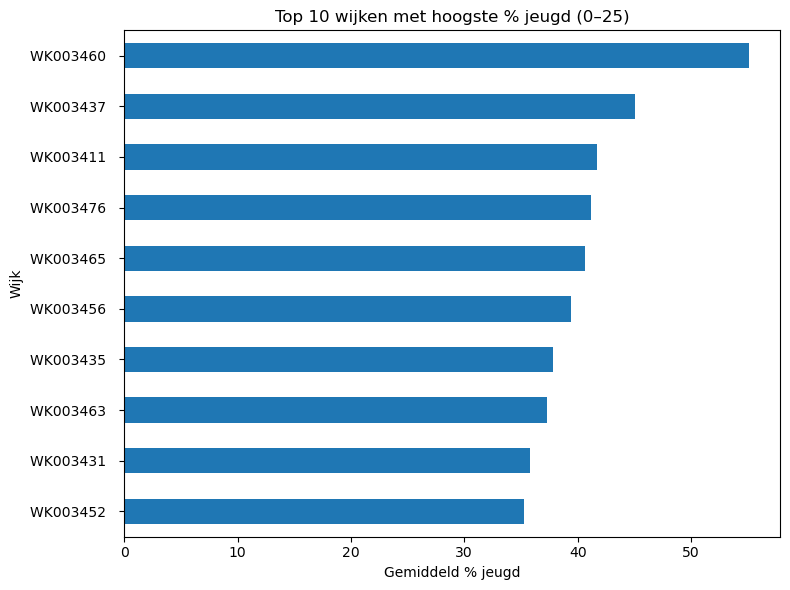

In [178]:
gemiddeld_wijk = df.groupby("Wijk")["Perc_TotaleJeugd"].mean()
top10_wijk = gemiddeld_wijk.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
top10_wijk.sort_values().plot(kind="barh")
plt.title("Top 10 wijken met hoogste % jeugd (0–25)")
plt.xlabel("Gemiddeld % jeugd")
plt.tight_layout()
plt.show()

**Tijdreeks per wijk (Bo + Ismael)**

In [181]:
# Totale jeugd berekenen
df["Totale_Jeugd"] = df["Aantal_0_15"] + df["Aantal_15_25"]

# Top 10 wijken bepalen
top10_wijken = (
    df.groupby("Wijk")["Totale_Jeugd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

print("Top 10 wijken:", list(top10_wijken))

Top 10 wijken: ['WK003402  ', 'WK003403  ', 'WK003401  ', 'WK003427  ', 'WK003424  ', 'WK003430  ', 'WK003418  ', 'WK003428  ', 'WK003404  ', 'WK003463  ']


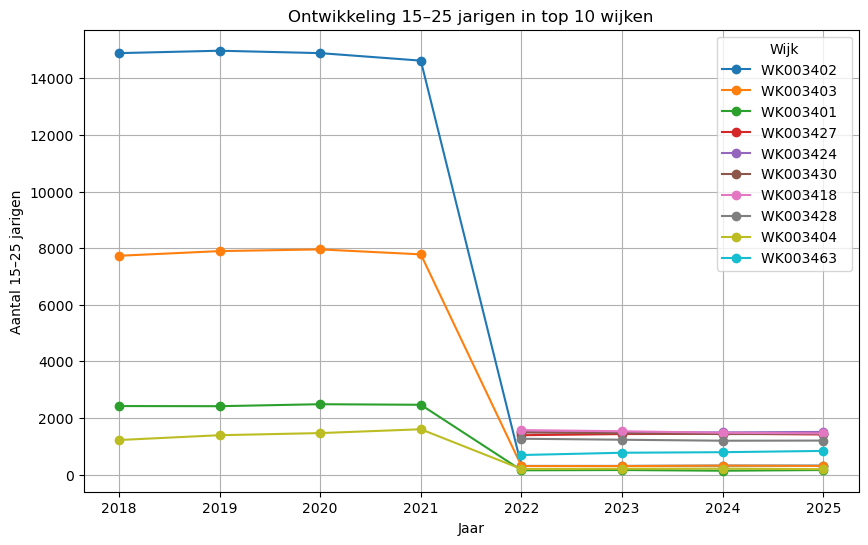

In [183]:
plt.figure(figsize=(10,6))

for wijk in top10_wijken:
    
    subset = df[df["Wijk"] == wijk].sort_values("Jaar")

    plt.plot(
        subset["Jaar"],
        subset["Aantal_15_25"],
        marker="o",
        label=wijk
    )

plt.xlabel("Jaar")
plt.ylabel("Aantal 15–25 jarigen")
plt.title("Ontwikkeling 15–25 jarigen in top 10 wijken")

plt.legend(title="Wijk")
plt.grid(True)

plt.show()

**Bo’s stadsdeel mapping (alleen als WijkCode WK003401 etc.)**

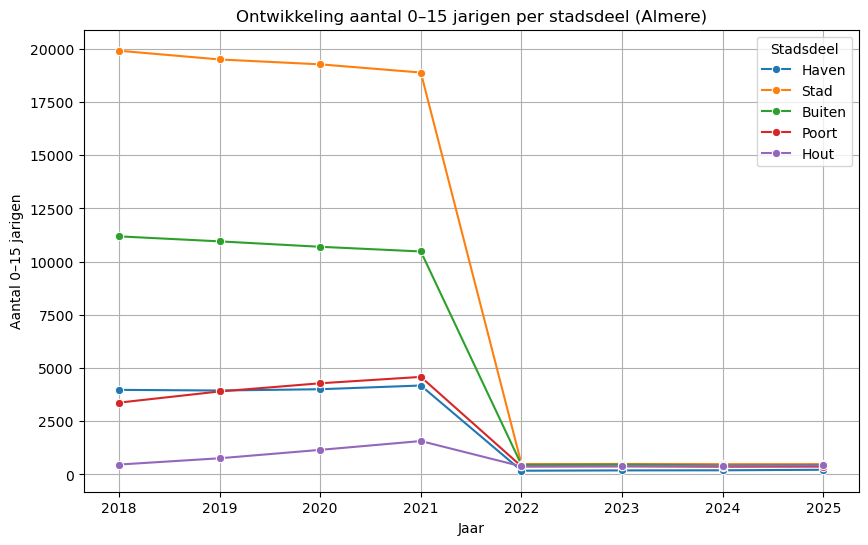

In [184]:
# Mapping wijkcodes -> stadsdelen
wijk_mapping = {
    "WK003401": "Haven",
    "WK003402": "Stad",
    "WK003403": "Buiten",
    "WK003404": "Poort",
    "WK003405": "Hout",
}

df["Stadsdeel"] = df["WijkCode"].map(wijk_mapping)

df_map = df.dropna(subset=["Stadsdeel"]).copy()

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_map,
    x="Jaar",
    y="Aantal_0_15",
    hue="Stadsdeel",
    marker="o"
)

plt.title("Ontwikkeling aantal 0–15 jarigen per stadsdeel (Almere)")
plt.xlabel("Jaar")
plt.ylabel("Aantal 0–15 jarigen")

plt.grid(True)

plt.legend(title="Stadsdeel")

plt.show()

## Modeling
We gebruiken lineaire regressie als baseline model.

## Evaluatie

## Visualisatie Resultaten

## Conclusie
- Hoe goed presteert het model?
- Is het bruikbaar voor de gemeente?
- Wat zijn beperkingen?
- Aanbevelingen voor vervolgonderzoek.